<a href="https://colab.research.google.com/github/Harshithpalan/Deep-Lerning-python-experiments/blob/main/cifar_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

 1. Load and preprocess CIFAR-10

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


# # Normalize pixel values to [0, 1]

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

## CIFAR-10 class names

In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

2. Data augmentation

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

3. Define CNN model

In [ ]:
model = models.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),  # 10 classes
    ]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # integer labels 0–9
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_acc"),
    ],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

 4. Callbacks (EarlyStopping + ModelCheckpoint)

In [ ]:
checkpoint_path = "cifar10_best.keras"

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

earlystop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min",
    restore_best_weights=True,
    verbose=1,
)

callbacks = [checkpoint_cb, earlystop_cb]


5. Train the model

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,              # EarlyStopping will likely stop earlier
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.2613 - loss: 2.1276 - top5_acc: 0.4673
Epoch 1: val_accuracy improved from None to 0.14950, saving model to cifar10_best.keras

Epoch 1: finished saving model to cifar10_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 186s 232ms/step - accuracy: 0.3129 - loss: 1.9083 - top5_acc: 0.4760 - val_accuracy: 0.1495 - val_loss: 3.1667 - val_top5_acc: 0.0044
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.3843 - loss: 1.6962 - top5_acc: 0.4889
Epoch 2: val_accuracy improved from 0.14950 to 0.30480, saving model to cifar10_best.keras

Epoch 2: finished saving model to cifar10_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 157s 200ms/step - accuracy: 0.3999 - loss: 1.6523 - top5_acc: 0.4794 - val_accuracy: 0.3048 - val_loss: 2.1800 - val_top5_acc: 0.8638
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.4308 - loss: 1.5707 - top5_acc: 0.4747
Epoch 3: val_accuracy improved from 0.30480 to 0.31860, saving mod

6. Training curves (accuracy, loss, top-5 acc)

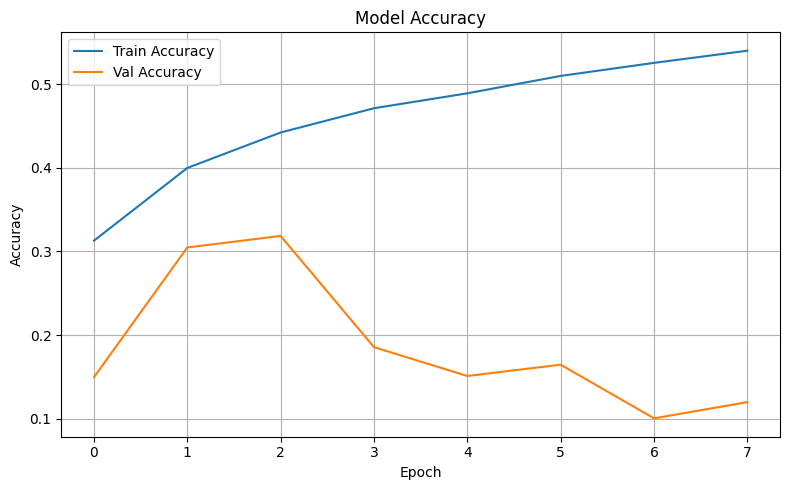

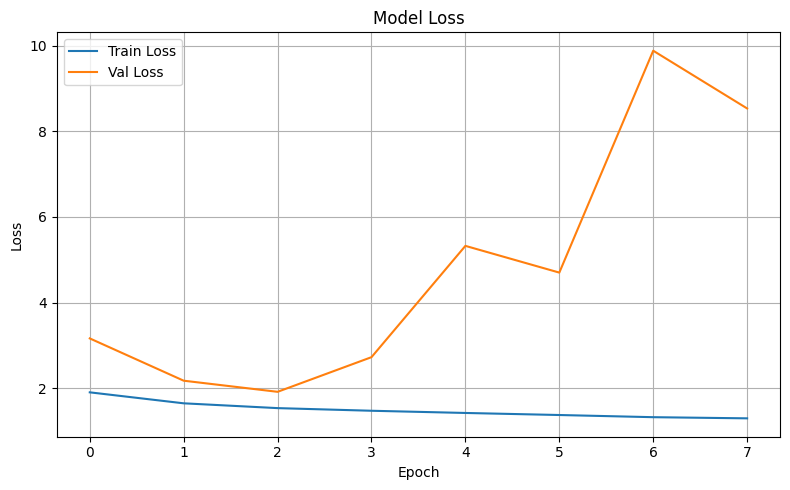

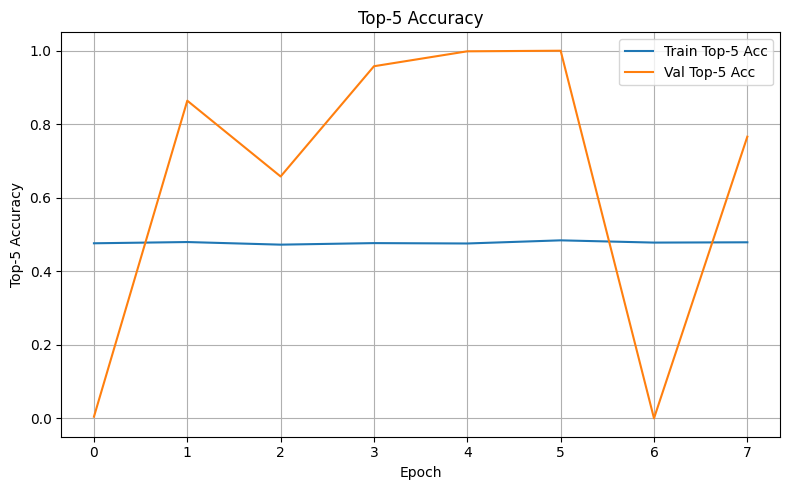

In [ ]:
def plot_history(history):
    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Top-5 accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["top5_acc"], label="Train Top-5 Acc")
    plt.plot(history.history["val_top5_acc"], label="Val Top-5 Acc")
    plt.title("Top-5 Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Top-5 Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_history(history)


 7. Sample images visualization

/tmp/ipykernel_523/845101493.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = class_names[int(y[idx])]


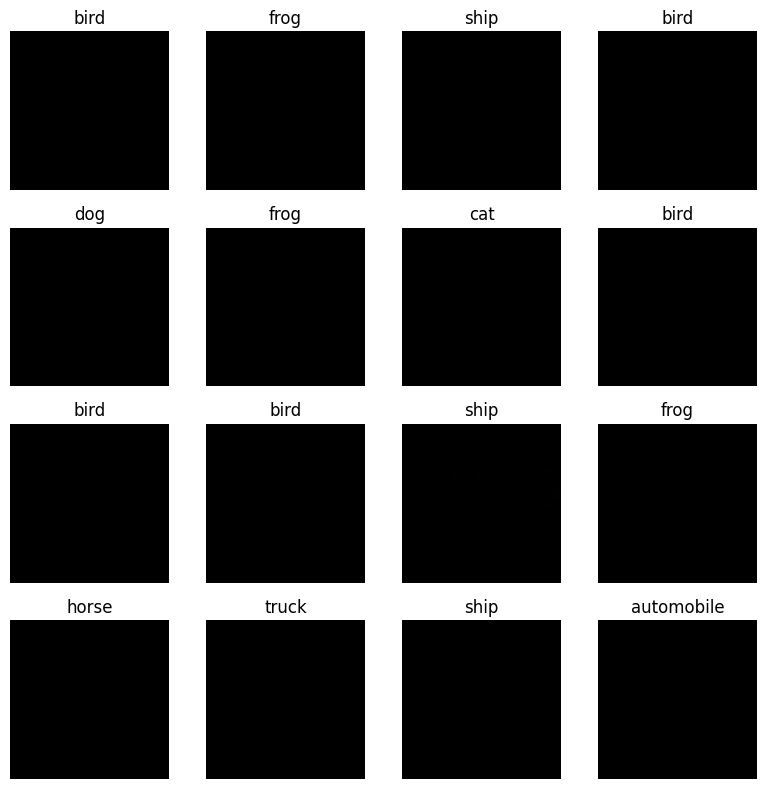

In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def show_sample_images(x, y, n=16):
    plt.figure(figsize=(8, 8))
    indices = np.random.choice(len(x), n, replace=False)
    for i, idx in enumerate(indices):
        plt.subplot(4, 4, i + 1)
        plt.imshow(x[idx])
        label = class_names[int(y[idx])]
        plt.title(label)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(x_train, y_train, n=16)


79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step


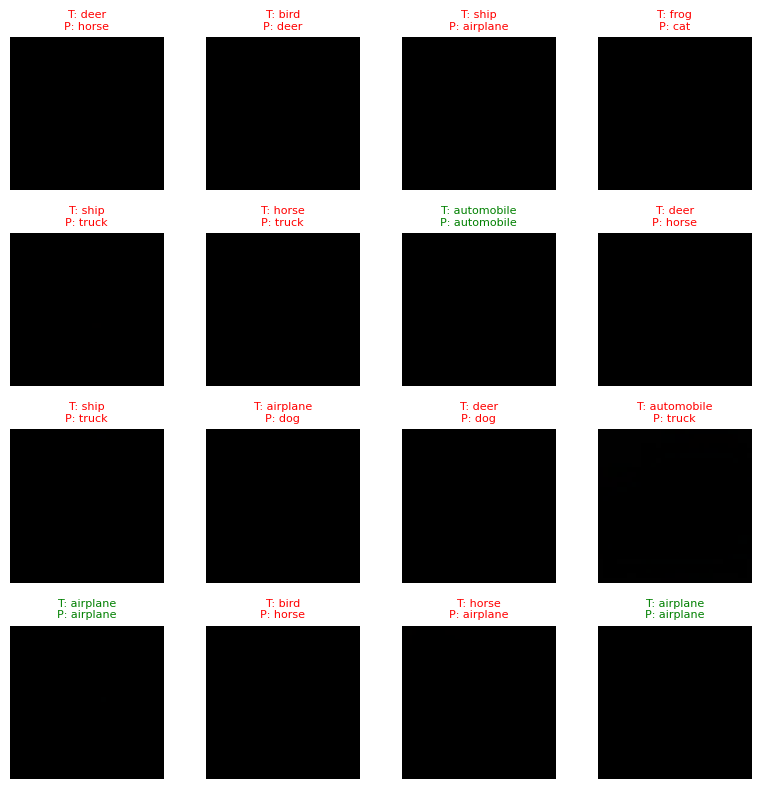

In [ ]:
y_prob = model.predict(x_test, batch_size=128)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.squeeze()

def show_predictions(x, y_true, y_pred, n=16):
    plt.figure(figsize=(8, 8))
    indices = np.random.choice(len(x), n, replace=False)
    for i, idx in enumerate(indices):
        plt.subplot(4, 4, i + 1)
        plt.imshow(x[idx])
        true_label = class_names[int(y_true[idx])]
        pred_label = class_names[int(y_pred[idx])]
        color = "green" if y_true[idx] == y_pred[idx] else "red"
        plt.title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(x_test, y_true, y_pred, n=16)

9. Confusion matrix

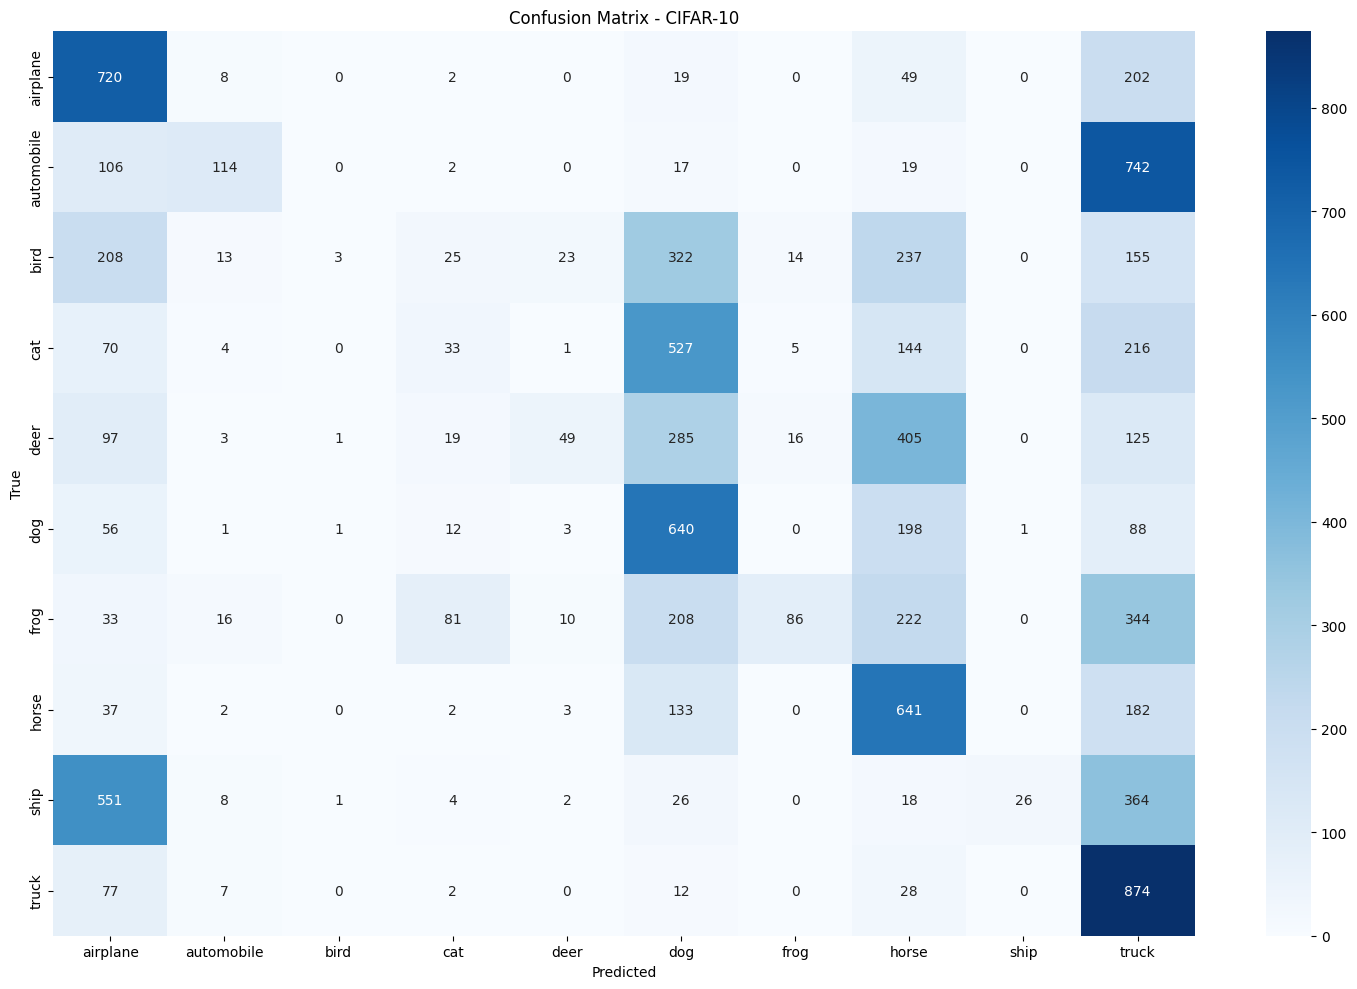

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CIFAR-10")
plt.tight_layout()
plt.show()